In [20]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import os
import cv2

files = os.listdir(r"C:\Users\YC\Desktop\Assinment3\Training_dataSet")

for file in files:
    image = cv2.imread(r"C:\Users\YC\Desktop\Assinment3\Training_dataSet\\"+file)

    if image is not None:
        image = cv2.resize(image,(64,64))
        cv2.imwrite(r"C:\Users\YC\Desktop\Assinment3\Training_dataSet\\" +file,image)
    else:
        print("Failed to read image")
        
image1=[]
label_list= []
for file in files:
    if("car" in file):
        label = 1    #for car
    else:
        label = 0   #for not car
    image_path_1 = r"C:\Users\YC\Desktop\Assinment3\Training_dataSet\\"+ file
    image = cv2.imread(image_path_1)
    image=cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image1.append(image)
    label_list.append(label) 

#create hdf5 file
with h5py.File("train_cars.h5", "w") as hf:
    train_set_x = hf.create_dataset("train_set_x", data=image1)
    train_set_y = hf.create_dataset("train_set_y", data=label_list)

#Apply same procedure for testing data set    

files = os.listdir(r"C:\Users\YC\Desktop\Assinment3\Test_DataSet")

for file in files:
    image = cv2.imread(r"C:\Users\YC\Desktop\Assinment3\Test_DataSet\\"+file)
    #print(file)
    if image is not None:
        image = cv2.resize(image,(64,64))
        cv2.imwrite(r"C:\Users\YC\Desktop\Assinment3\Test_DataSet\\" +file,image)
    else:
        print("Failed to read image")
        
image_test=[]
label_list_test= []
for file in files:
    if("car" in file):
        label = 1    #for car
    else:
        label = 0   #for not car
    image_path_1 = r"C:\Users\YC\Desktop\Assinment3\Test_DataSet\\"+ file
    image = cv2.imread(image_path_1)
    image=cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image_test.append(image)
    label_list_test.append(label) 

#create hdf5 file
with h5py.File("test_cars.h5", "w") as hf:
    test_set_x = hf.create_dataset("test_set_x", data=image_test)
    test_set_y = hf.create_dataset("test_set_y", data=label_list_test)     
classes = classes = np.unique(label_list + label_list_test) 


In [21]:
import numpy as np
import h5py
    
    
def load_dataset():
    train_dataset = h5py.File('train_cars.h5', "r")
    train_set_x_orig = np.array(train_dataset["train_set_x"][:]) # your train set features
    train_set_y_orig = np.array(train_dataset["train_set_y"][:]) # your train set labels

    test_dataset = h5py.File('test_cars.h5', "r")
    test_set_x_orig = np.array(test_dataset["test_set_x"][:]) # your test set features
    test_set_y_orig = np.array(test_dataset["test_set_y"][:]) # your test set labels

    classes = np.array(['Not Car', 'Car']) # the list of classes
    
    train_set_y_orig = train_set_y_orig.reshape((1, train_set_y_orig.shape[0]))
    test_set_y_orig = test_set_y_orig.reshape((1, test_set_y_orig.shape[0]))
    
    return train_set_x_orig, train_set_y_orig, test_set_x_orig, test_set_y_orig, classes

train_set_x_orig, train_set_y, test_set_x_orig, test_set_y, classes = load_dataset()

y = [0], it's a 'Not Car' picture.


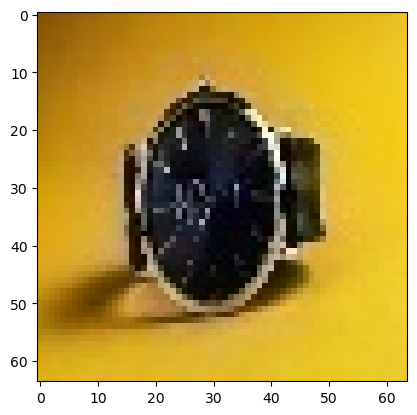

In [22]:
index = 10
plt.imshow(train_set_x_orig[index])
print ("y = " + str(train_set_y[:, index]) + ", it's a '" + classes[np.squeeze(train_set_y[:, index])] +  "' picture.")

In [23]:
m_train = train_set_x_orig.shape[0]
m_test = test_set_x_orig.shape[0]
num_px = train_set_x_orig.shape[1]
### END CODE HERE ###

print ("Number of training examples: m_train = " + str(m_train))
print ("Number of testing examples: m_test = " + str(m_test))
print ("Height/Width of each image: num_px = " + str(num_px))
print ("Each image is of size: (" + str(num_px) + ", " + str(num_px) + ", 3)")
print ("train_set_x shape: " + str(train_set_x_orig.shape))
print ("train_set_y shape: " + str(train_set_y.shape))
print ("test_set_x shape: " + str(test_set_x_orig.shape))
print ("test_set_y shape: " + str(test_set_y.shape))
     

Number of training examples: m_train = 180
Number of testing examples: m_test = 55
Height/Width of each image: num_px = 64
Each image is of size: (64, 64, 3)
train_set_x shape: (180, 64, 64, 3)
train_set_y shape: (1, 180)
test_set_x shape: (55, 64, 64, 3)
test_set_y shape: (1, 55)


In [24]:
# Reshape the training and test examples
# train_set_x_orig, train_set_y, test_set_x_orig, test_set_y, classes
### START CODE HERE ### (≈ 2 lines of code)
train_set_x_flatten = train_set_x_orig.reshape(train_set_x_orig.shape[0], -1).T
test_set_x_flatten = test_set_x_orig.reshape(test_set_x_orig.shape[0], -1).T
### END CODE HERE ###

print ("train_set_x_flatten shape: " + str(train_set_x_flatten.shape))
print ("train_set_y shape: " + str(train_set_y.shape))
print ("test_set_x_flatten shape: " + str(test_set_x_flatten.shape))
print ("test_set_y shape: " + str(test_set_y.shape))
print ("sanity check after reshaping: " + str(train_set_x_flatten[0:5,0]))

train_set_x_flatten shape: (12288, 180)
train_set_y shape: (1, 180)
test_set_x_flatten shape: (12288, 55)
test_set_y shape: (1, 55)
sanity check after reshaping: [228 237 244 228 237]


In [25]:

train_set_x = train_set_x_flatten/255.
test_set_x = test_set_x_flatten/255.

In [27]:
def sigmoid(z):
    """
    Compute the sigmoid of z

    Arguments:
    z -- A scalar or numpy array of any size.

    Return:
    s -- sigmoid(z)
    """

    ### START CODE HERE ### (≈ 1 line of code)
    s = 1 /(1 + np.exp(-z))
    ### END CODE HERE ###
    
    return s
     

print ("sigmoid([0, 2]) = " + str(sigmoid(np.array([0,2]))))
def initialize_with_zeros(dim):
    """
    This function creates a vector of zeros of shape (dim, 1) for w and initializes b to 0.
    
    Argument:
    dim -- size of the w vector we want (or number of parameters in this case)
    
    Returns:
    w -- initialized vector of shape (dim, 1)
    b -- initialized scalar (corresponds to the bias)
    """
    
    ### START CODE HERE ### (≈ 1 line of code)
    w = np.zeros(shape=(dim, 1), dtype=np.float32)
    b = 0
    ### END CODE HERE ###

    assert(w.shape == (dim, 1))
    assert(isinstance(b, float) or isinstance(b, int))
    
    return w, b
     

dim = 2
w, b = initialize_with_zeros(dim)
print ("w = " + str(w))
print ("b = " + str(b))

sigmoid([0, 2]) = [0.5        0.88079708]
w = [[0.]
 [0.]]
b = 0


In [32]:
def propagate(w, b, X, Y):
    """
    Implement the cost function and its gradient for the propagation explained above

    Arguments:
    w -- weights, a numpy array of size (num_px * num_px * 3, 1)
    b -- bias, a scalar
    X -- data of size (num_px * num_px * 3, number of examples)
    Y -- true "label" vector (containing 0 if non-cat, 1 if cat) of size (1, number of examples)

    Return:
    cost -- negative log-likelihood cost for logistic regression
    dw -- gradient of the loss with respect to w, thus same shape as w
    db -- gradient of the loss with respect to b, thus same shape as b
    
    Tips:
    - Write your code step by step for the propagation. np.log(), np.dot()
    """
    
    m = X.shape[1]
    
    # FORWARD PROPAGATION (FROM X TO COST)
    ### START CODE HERE ### (≈ 2 lines of code)
    A = sigmoid(np.dot(w.T, X) + b)  # compute activation
    cost = (-1./m)*np.sum((Y*np.log(A)+(1-Y)*np.log(1-A)), axis=1) # compute cost
    ### END CODE HERE ###
    
    # BACKWARD PROPAGATION (TO FIND GRAD)
    ### START CODE HERE ### (≈ 2 lines of code)
    dw = (1./m)*np.dot(X,((A-Y).T))
    db = (1./m)*np.sum(A-Y, axis=1)
    ### END CODE HERE ###

    assert(dw.shape == w.shape)
    assert(db.dtype == float)
    cost = np.squeeze(cost)
    assert(cost.shape == ())
    
    grads = {"dw": dw,
             "db": db}
    
    return grads, cost
     

w, b, X, Y = np.array([[1.],[2.]]), 2., np.array([[1.,2.,-1.],[3.,4.,-3.2]]), np.array([[1,0,1]])
grads, cost = propagate(w, b, X, Y)
print("Propagation: ")
print ("dw = " + str(grads["dw"]))
print ("db = " + str(grads["db"]))
print ("cost = " + str(cost))
    
    
def optimize(w, b, X, Y, num_iterations, learning_rate, print_cost = False):
    """
    This function optimizes w and b by running a gradient descent algorithm
    
    Arguments:
    w -- weights, a numpy array of size (num_px * num_px * 3, 1)
    b -- bias, a scalar
    X -- data of shape (num_px * num_px * 3, number of examples)
    Y -- true "label" vector (containing 0 if non-cat, 1 if cat), of shape (1, number of examples)
    num_iterations -- number of iterations of the optimization loop
    learning_rate -- learning rate of the gradient descent update rule
    print_cost -- True to print the loss every 100 steps
    
    Returns:
    params -- dictionary containing the weights w and bias b
    grads -- dictionary containing the gradients of the weights and bias with respect to the cost function
    costs -- list of all the costs computed during the optimization, this will be used to plot the learning curve.
    
    Tips:
    You basically need to write down two steps and iterate through them:
        1) Calculate the cost and the gradient for the current parameters. Use propagate().
        2) Update the parameters using gradient descent rule for w and b.
    """
    
    costs = []
    
    for i in range(num_iterations):
        
        
        # Cost and grad ient calculation (≈ 1-4 lines of code)
        ### START CODE HERE ### 
        grads, cost = propagate(w=w, b=b, X=X, Y=Y)
        ### END CODE HERE ###
        
        # Retrieve derivatives from grads
        dw = grads["dw"]
        db = grads["db"]
        
        # update rule (≈ 2 lines of code)
        ### START CODE HERE ###
        w = w - learning_rate*dw
        b = b - learning_rate*db
        ### END CODE HERE ###
        
        # Record the costs
        if i % 100 == 0:
            costs.append(cost)
        
        # Print the cost every 100 training iterations
        if print_cost and i % 100 == 0:
            print ("Cost after iteration %i: %f" %(i, cost))
    
    params = {"w": w,
              "b": b}
    
    grads = {"dw": dw,
             "db": db}
    
    return params, grads, costs
     

params, grads, costs = optimize(w, b, X, Y, num_iterations= 100, learning_rate = 0.009, print_cost = False)
print("____________")
print("Optimization: ")
print ("w = " + str(params["w"]))
print ("b = " + str(params["b"]))
print ("dw = " + str(grads["dw"]))
print ("db = " + str(grads["db"]))
def predict(w, b, X):
    '''
    Predict whether the label is 0 or 1 using learned logistic regression parameters (w, b)
    
    Arguments:
    w -- weights, a numpy array of size (num_px * num_px * 3, 1)
    b -- bias, a scalar
    X -- data of size (num_px * num_px * 3, number of examples)
    
    Returns:
    Y_prediction -- a numpy array (vector) containing all predictions (0/1) for the examples in X
    '''
    
    m = X.shape[1]
    Y_prediction = np.zeros((1,m))
    w = w.reshape(X.shape[0], 1)
    
    # Compute vector "A" predicting the probabilities of a cat being present in the picture
    ### START CODE HERE ### (≈ 1 line of code)
    A = sigmoid(np.dot(w.T, X) + b)
    ### END CODE HERE ###
    
    for i in range(A.shape[1]):
        
        # Convert probabilities A[0,i] to actual predictions p[0,i]
        ### START CODE HERE ### (≈ 4 lines of code)
        if A[0, i] >= 0.5:
            Y_prediction[0, i] = 1            
        else:
            Y_prediction[0, i] = 0
        ### END CODE HERE ###
    
    assert(Y_prediction.shape == (1, m))
    
    return Y_prediction
     

w = np.array([[0.1124579],[0.23106775]])
b = -0.3
X = np.array([[1.,-1.1,-3.2],[1.2,2.,0.1]])
print("_________")
print ("predictions = " + str(predict(w, b, X)))
     

Propagation: 
dw = [[0.99845601]
 [2.39507239]]
db = [0.00145558]
cost = 5.801545319394553
____________
Optimization: 
w = [[0.19033591]
 [0.12259159]]
b = [1.92535983]
dw = [[0.67752042]
 [1.41625495]]
db = [0.2191945]
_________
predictions = [[1. 1. 0.]]


In [33]:
def model(X_train, Y_train, X_test, Y_test, num_iterations = 2000, learning_rate = 0.5, print_cost = False):
    """
    Builds the logistic regression model by calling the function you've implemented previously
    
    Arguments:
    X_train -- training set represented by a numpy array of shape (num_px * num_px * 3, m_train)
    Y_train -- training labels represented by a numpy array (vector) of shape (1, m_train)
    X_test -- test set represented by a numpy array of shape (num_px * num_px * 3, m_test)
    Y_test -- test labels represented by a numpy array (vector) of shape (1, m_test)
    num_iterations -- hyperparameter representing the number of iterations to optimize the parameters
    learning_rate -- hyperparameter representing the learning rate used in the update rule of optimize()
    print_cost -- Set to true to print the cost every 100 iterations
    
    Returns:
    d -- dictionary containing information about the model.
    """
    
    ### START CODE HERE ###
    
    # initialize parameters with zeros (≈ 1 line of code)
    w, b = initialize_with_zeros(X_train.shape[0])

    # Gradient descent (≈ 1 line of code)
    parameters, grads, costs = optimize(w, b, X_train, Y_train, num_iterations, learning_rate, print_cost)
    
    # Retrieve parameters w and b from dictionary "parameters"
    w = parameters["w"]
    b = parameters["b"]
    
    # Predict test/train set examples (≈ 2 lines of code)
    Y_prediction_test = predict(w, b, X_test)
    Y_prediction_train = predict(w, b, X_train)

    ### END CODE HERE ###

    # Print train/test Errors
    print("train accuracy: {} %".format(100 - np.mean(np.abs(Y_prediction_train - Y_train)) * 100))
    print("test accuracy: {} %".format(100 - np.mean(np.abs(Y_prediction_test - Y_test)) * 100))

    
    d = {"costs": costs,
         "Y_prediction_test": Y_prediction_test, 
         "Y_prediction_train" : Y_prediction_train, 
         "w" : w, 
         "b" : b,
         "learning_rate" : learning_rate,
         "num_iterations": num_iterations}
    
    return d
d = model(train_set_x, train_set_y, test_set_x, test_set_y, num_iterations = 2000, learning_rate = 0.005, print_cost = True)


Cost after iteration 0: 0.693147
Cost after iteration 100: 0.417402
Cost after iteration 200: 0.242349
Cost after iteration 300: 0.190812
Cost after iteration 400: 0.163514
Cost after iteration 500: 0.143215
Cost after iteration 600: 0.127430
Cost after iteration 700: 0.114800
Cost after iteration 800: 0.104476
Cost after iteration 900: 0.095889
Cost after iteration 1000: 0.088641
Cost after iteration 1100: 0.082447
Cost after iteration 1200: 0.077097
Cost after iteration 1300: 0.072433
Cost after iteration 1400: 0.068332
Cost after iteration 1500: 0.064701
Cost after iteration 1600: 0.061465
Cost after iteration 1700: 0.058564
Cost after iteration 1800: 0.055949
Cost after iteration 1900: 0.053581
train accuracy: 99.44444444444444 %
test accuracy: 90.9090909090909 %


y = 1, you predicted that it is a "Car" picture.


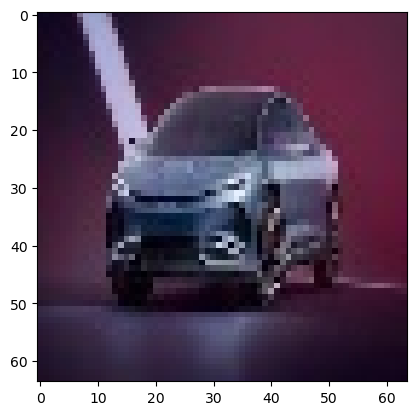

In [39]:
index = 0
plt.imshow(test_set_x[:, index].reshape((num_px, num_px, 3)))
print("y = " + str(test_set_y[0, index]) + ", you predicted that it is a \"" + classes[int(np.squeeze(d["Y_prediction_test"][:, index]))] + "\" picture.")
